- The last layer(s) of the network should be a classifier for sentiment polarity, and should be designed by you. There is no requirement on the technical complexity of this classifier. This implies that you can't just load a ready-made pipeline.
- Use pyTorch's Dataset and DataLoader classes for loading the data.
- Train the network using batches of at least 2.
- Compare performance between some model and a similar distilled one (e.g. BERT and DistilBERT).


# Sentimentanalys för antik grekiska (assignment 3, Machine Learning for NLP)

# Plan och förberedelse

In [23]:
import torch
print(torch.__version__)
print(torch.__file__)

torch.set_default_dtype(torch.float32)

if torch.xpu.is_available():
    device = torch.device("xpu:0")
    max_memory = torch.xpu.max_memory_allocated
    available, total = torch.xpu.mem_get_info(device)
    print(f"{total / 1024 ** 3:.1f} GB, {100 * available / total:.1f}% tillgängligt.")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
    max_memory = torch.xpu.max_memory_allocated
else:
    device = torch.device("cpu")

2.8.0+xpu
/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/torch/__init__.py
11.3 GB, 100.0% tillgängligt.


KaLM 2.5 är en lite kinkig modell som varken gillar senaste transformers eller för gamla versioner. En fungerande setup är `transformers 4.57.6` och `sentence-transformers 5.0.0`

In [6]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

import sentence_transformers
print(sentence_transformers.__version__)
print(transformers.__file__)

4.37.0
/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/transformers/__init__.py
5.3.0
/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/transformers/__init__.py


# Embeddings

Först laddar vi och förbereder datan som ska embeddas. Jag har två filer: en med 300 meningar från Emelie. Dessa är från romerska/bysantinska romaner. Den andra är 30 meningar från Aristofanes som jag själv klassificerat.

In [7]:
with open("../tsv/sentiment_aristophanes.tsv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    sentences_albin = [line.split("\t")[0] for line in lines[1:]]
    labels_albin = [line.split("\t")[1].replace("\n", "") for line in lines[1:]]

# vi förbereder också Emelies:
with open("../tsv/sentiment_romaner.tsv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    sentences_emelie = [line.split("\t")[0] for line in lines[1:]]
    labels_emelie = [line.split("\t")[1].replace("\n", "") for line in lines[1:]]

random_start = torch.randint(low=1, high=len(sentences_albin) + 1 - 10, size=(1,)).item()
end = random_start + 3

print("Vi checkar några exempel, t.ex. 3 meningar från och med mening nummer",random_start, ":\n")
for sentence, label in zip(sentences_albin[random_start: end], labels_albin[random_start: end]):
    print(sentence[:30], ": ", label)

# Manualen för F.cross_entropy säger att "each value should be between [0,C)". Med C = 3, får vi [0, 1, 2]
label_map = {
    "NEG": 0,
    "NEU": 1,
    "POS": 2
}

print(labels_albin[:10])

labels_albin = [label_map[l] for l in labels_albin]
labels_emelie = [label_map[l] for l in labels_emelie]

print(labels_albin[:10])

Vi checkar några exempel, t.ex. 3 meningar från och med mening nummer 3 :

ἃ δ' ὠδυνήθην, ψαμμακοσιογάργα :  NEG
καὶ φιλῶ τοὺς ἱππέας διὰ τοῦτο :  POS
φιλῶ τοὺς ἱππέας :  POS
['POS', 'POS', 'POS', 'NEG', 'POS', 'POS', 'POS', 'POS', 'POS', 'POS']
[2, 2, 2, 0, 2, 2, 2, 2, 2, 2]


In [4]:
from sentence_transformers import SentenceTransformer
import torch

model = SentenceTransformer(
    "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5",
    trust_remote_code=True,
    model_kwargs={
        "dtype": torch.float32,
        "attn_implementation": "eager",                                                               # kan ej få "pip install flash_attn" att gå igenom på klustret, ens i en container och fem timmars försök
    },
)
model.max_seq_length = 512

embeddings_emelie = model.encode(                                                                          # embeddings.shape == (num_sentences, 896)
    sentences_emelie,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
    precision="float32",
    convert_to_tensor=True,                                                                         # default är numpy array, vilket ger vårt hemmabyggda torch lager nedan hicka, så vi ber snällt om tensorer...
)

embeddings_albin = model.encode(
    sentences_albin,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
    precision="float32",
    convert_to_tensor=True,
)

print("Vi inspekterar några av exempelmeningarna:")
print(embeddings_emelie[random_start: end])

# jag sparar vektorerna, eftersom för att generera dem krävs det en CUDA-gpu från klustret,
# men när de väl är nere så finns det inget som stoppar mig från att arbeta vidare lokalt
torch.save(embeddings_emelie, "../embed/sentiment_embeddings_emelie.pt")
torch.save(embeddings_albin, "../embed/sentiment_embeddings_albin.pt")


/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


ImportError: This modeling file requires the following packages that were not found in your environment: flash_attn. Run `pip install flash_attn`

# Dataset och DataLoader

Först definierar vi datasetets klass. Den hårda vägen lär man sig att dataset måste servera tensorerna till dataloadern från CPUn och inte GPUn.

In [8]:
from torch.utils.data import Dataset, DataLoader

class SentimentEmbeddingsDataset(Dataset):
    """
    Dataset consisting of 896-dimensional KaLM 2.5 embeddings of Ancient Greek sentences,
    and labels marking sentences as 0, 1, 2 for negative, neutral and positive sentiment respectively.
    
    Input tensors must have device="cpu"!
    
    The dtypes are important for CE loss calculation:
        Embeddings dtype: torch.float32 = torch.float
        Labels dtype: torch.int64 = torch.long
    """

    def __init__(self, embeddings: torch.Tensor, labels: torch.Tensor, transform=None):     # torch ger type hints för sina tensorer
        self.X = embeddings
        self.Y = labels
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        x = self.X[idx]
        y = self.Y[idx]

        if self.transform:
            x = self.transform(x)

        return x, y                                                                         # en embedding och dess sentimentlabel

Vi gör en train/val/test-split. Val (a.k.a. "dev") kommer vi använda för att räkna ut efter hur många epoker träningen är färdig genom att sätta en "patience", d.v.s. efter hur många epoker vi avslutar träningen om accuracy på val inte ökar.

Vi förbereder för tre experiment:
- "baseline": vi tränar med Emelies train och val och testar med Emelies test (80/10/10 split)
- se om träningsdata från en annan genre och epok hjälper på Emelies test-set
- omvänt: se vad träning på Emelies data ger för resultat på test från en annan genre och epok

Notera att alla tensorer läggs på CPUn inför att dataloadern ska jobba.

In [9]:
# 1. Ladda alla embeddings

emelie = torch.load("../embed/sentiment_embeddings_test.pt", map_location=torch.device("cpu"))
emelie = emelie.float()                                                                                                                              # parametermatrisen är float32 och för att matmul i forward() ska gå igenom försäkrar vi oss om att embeddingsmatrisen inte är float16
emelie_labels = torch.tensor(labels_emelie, dtype=torch.long, device=torch.device("cpu"))                                                              # vi gör om Emelies labels till en tensor också, så att vi kan använda den i dataloadern

albin = torch.load("../embed/sentiment_embeddings.pt", map_location=torch.device("cpu"))
albin = albin.float()
albin_labels = torch.tensor(labels_albin, dtype=torch.long, device=torch.device("cpu"))

print(emelie.shape)
print(emelie_labels.shape)

print(albin.shape)
print(albin_labels.shape)

# 2. Räkna ut split för test, val och train (samma för alla experiment)

def split(embeddings: torch.Tensor, labels: torch.Tensor, test_part=1/10, val_part=1/10):
    """
    Vi gör en gemensam funktion för att undvika att duplicera kod för varje experiment.
    """
    length = embeddings.shape[0]

    test_size = int(length * test_part)
    val_size = int(length * val_part)
    train_size = length - test_size - val_size                                                                          # vid ojämn delning, ger vi det som blir över till train, så att vi inte tappar data

    # Train / val / test
    if test_part != 0:
        test, val, train = torch.split(embeddings, [test_size, val_size, train_size])          # torch.split tar en lista av custom längder. (om man ger en enda int delar den i lika delar så gott det går)
        test_labels, val_labels, train_labels = torch.split(labels, [test_size, val_size, train_size])

        assert train.shape[0] == train_labels.shape[0]
        assert val.shape[0] == val_labels.shape[0]
        assert test.shape[0] == test_labels.shape[0]
        
        return train, train_labels, val, val_labels, test, test_labels
    
    else:
        val, train = torch.split(embeddings, [val_size, train_size])
        val_labels, train_labels = torch.split(labels, [val_size, train_size])
        
        assert train.shape[0] == train_labels.shape[0]
        assert val.shape[0] == val_labels.shape[0]
        
        return train, train_labels, val, val_labels, None, None

# 3. Split för experiment 1: baseline med bara Emelies data

train_1, train_labels_1, val_1, val_labels_1, test_1, test_labels_1 = split(emelie, emelie_labels, test_part=1/10, val_part=1/10)

print("\nEXPERIMENT 1: Baseline med bara Emelies data")
print("Train: ", train_1.shape)
print("Val: ", val_1.shape)
print("Test: ", test_1.shape)

# 4. Split för experiment 2: Emelies data + mina egna data som extra train och val, Emelies data som test

all = torch.cat([emelie, albin], dim=0)
labels_all = torch.cat([emelie_labels, albin_labels], dim=0)

train_2, train_labels_2, val_2, val_labels_2, test_2, test_labels_2 = split(all, labels_all, test_part=1/10, val_part=1/10)

print("\nEXPERIMENT 2: Emelies data + mina egna data som extra train och val")
print("Train: ", train_2.shape)
print("Val: ", val_2.shape)
print("Test: ", test_2.shape)

# 5. Split för experiment 3: Emelies data som train och val, mina egna data som test

train_3, train_labels_3, val_3, val_labels_3, _, _ = split(all, labels_all, test_part=0/10, val_part=1/10)
test_3 = albin
test_labels_3 = labels_albin

print("\nEXPERIMENT 3: Emelies data som train, mina egna data som test")
print("Train: ", train_3.shape)
print("Val: ", val_3.shape)
print("Test: ", test_3.shape)

torch.Size([299, 896])
torch.Size([299])
torch.Size([34, 896])
torch.Size([34])

EXPERIMENT 1: Baseline med bara Emelies data
Train:  torch.Size([241, 896])
Val:  torch.Size([29, 896])
Test:  torch.Size([29, 896])

EXPERIMENT 2: Emelies data + mina egna data som extra train och val
Train:  torch.Size([267, 896])
Val:  torch.Size([33, 896])
Test:  torch.Size([33, 896])

EXPERIMENT 3: Emelies data som train, mina egna data som test
Train:  torch.Size([300, 896])
Val:  torch.Size([33, 896])
Test:  torch.Size([34, 896])


Nu kan vi skapa alla Dataset- och DataLoader-objekt. DataLoader tillåter enkel shuffle som lite data augmentation.

In [10]:
import os
import multiprocessing as mp
mp.set_start_method("fork", force=True)                                # från äldre python för linux fork subprocesser

# Inställningar #
batch_size = 32
shuffle = True
cores = os.cpu_count()

# Skapa objekten
dataset_train_1 = SentimentEmbeddingsDataset(train_1, train_labels_1)
dataset_test_1 = SentimentEmbeddingsDataset(test_1, test_labels_1)
dataset_train_2 = SentimentEmbeddingsDataset(train_2, train_labels_2)
dataset_test_2 = SentimentEmbeddingsDataset(test_2, test_labels_2)
dataset_train_3 = SentimentEmbeddingsDataset(train_3, train_labels_3)
dataset_test_3 = SentimentEmbeddingsDataset(test_3, test_labels_3)

dataloader_train_1 = DataLoader(dataset_train_1,
                        batch_size=batch_size,                             
                        shuffle=shuffle, 
                        num_workers=cores,
)
dataloader_test_1 = DataLoader(dataset_test_1,
                        batch_size=batch_size,                             
                        shuffle=shuffle, 
                        num_workers=cores,
)
dataloader_train_2 = DataLoader(dataset_train_2,
                        batch_size=batch_size,                             
                        shuffle=shuffle, 
                        num_workers=cores,
)
dataloader_test_2 = DataLoader(dataset_test_2,
                        batch_size=batch_size,                             
                        shuffle=shuffle, 
                        num_workers=cores,
)
dataloader_train_3 = DataLoader(dataset_train_3,
                        batch_size=batch_size,                             
                        shuffle=shuffle, 
                        num_workers=cores,
)
dataloader_test_3 = DataLoader(dataset_test_3,
                        batch_size=batch_size,                             
                        shuffle=shuffle, 
                        num_workers=cores,
)

# Linjärt lager

Vi designar vårt eget lager. Målet är att mappa från en batch av n 896-dimensionella vektorer till n tripletter av logits som symboliserar sentiment.

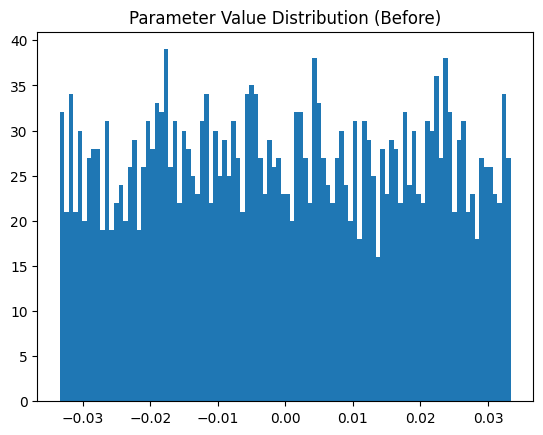

In [11]:
import matplotlib.pyplot as plt
import torch.nn as nn

class SentimentDecisionBoundariesLayer(nn.Module):                              # assuming good euclidean manifolds from the embedding model
    def __init__(self, embedding_dim):                                          # the dimensionality of the embedding
        super().__init__()
        self.linear = nn.Linear(in_features=embedding_dim, 
                                out_features=3,                                 # how many sentiment labels to get logits for! NEG, POS, NEU = 3
                                bias=True,
                                device=device,
                                dtype=torch.float32)      
    
    def forward(self, sentences):
        return self.linear.forward(sentences)

model_check = SentimentDecisionBoundariesLayer(embedding_dim=896)                     # the nr of dims of KaLM-Embedding-V2.5                                                  # inför träningen flyttar vi modellen till GPUn

params_before = torch.cat([p.detach().view(-1).cpu() for p in model_check.parameters()])
plt.hist(params_before.numpy(), bins=100)
plt.title("Parameter Value Distribution (Before)")
plt.show()

# Träningsloop

Vikterna initialiserade slumpmässigt som kan ses i plotten och ger som det är (ungefär) logits (0.33, 0.33, 0.33) för alla input. Modellen måste alltså tränas. Vi har redan förberett train / val / test splits.

Först måste vi designa träningsloopen, där det centrala är att definera en learning rate scheduler (optimizer) och en backward pass. Som optimiserare väljer jag Adam, som är en typ som jag har studerat och förstår något så när. Adam används till exempel i Stanza. 

Som objective function väljer jag cross entropy loss. Eftersom våra labels är one-hot så är detta samma som negativ log loss: - log p(korrekt sentiment). Eftersom NNL är definierad över sannolikheter så måste man först köra softmax på sina logits. Torch's `cross_entropy` är alltså i princip ett alias för `nll_loss(log_softmax(logits))` (ironiskt att nll_loss förväntar sig att log redan applicerats, trots att ett av l:en i namnet ju står för "log"...).

Jag använder också mitt val set för att implementera en typ av skydd mot överträning, genom att breaka träningsloopen om val loss inte sjunker under `patience` epoker i rad. `val_loss` initialiseras som `float("inf")`, vilket per definition ger `True` vid `>`-jämförelser med alla reella tal.

In [ ]:
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

print(device)

def train_and_validate(dataloader, val_inputs, val_targets, lr=1, betas=(0.9, 0.999), epsilon=1e-6, weight_decay=0, patience=10, par_plot=False, loss_plot=False, verbose=False):
    '''
    Creates a new SentimentDecisionBoundariesLayer, trains it on the data from dataloader and validates on val_inputs and val_targets.
    '''
    model = SentimentDecisionBoundariesLayer(embedding_dim=896)
    model.to(device)
    model.train()
    
    val_inputs = val_inputs.to(device)
    val_targets = val_targets.to(device)
    
    # Adam har fyra hyperparametrar (weight decay är valbart)
    # betas är skalkonstanter för gradienternas exponential running average och root mean square, deras "first and second moments" (ADAM = ADAptive Moment estimate)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        betas=betas,
        eps=epsilon,
        weight_decay=weight_decay,
    )

    _loss = []
    max_epochs = 100
    lowest_val_loss_so_far = float("inf")               # vi initialiserar godtyckligt högt för att garantera att patience inte ska börja ticka omedelbart
    for epoch in tqdm(range(max_epochs), unit="Epochs", leave=False):
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            logits = model(inputs)                   # ekvivalent med model.forward(inputs)
            
            loss = F.cross_entropy(logits, targets)       # blandning av Negative Log-Likelihood loss och softmax
            _loss.append(loss.item())

            optimizer.zero_grad()                          # sätt alla gradienter till noll innan vi räknas ut de nya gradienterna
            loss.backward()                                     # räknar ut partiell derivata av lossen med avseende på var och en av alla parametrar
            optimizer.step()                               # i korthet uppdaterar vi alla parametrar som ω_n = ω_{n-1} - η del(L), där η är en funktion av hyperparametrar och tidigare gradienter (lr scheduler)
            
        # val calculation
        model.eval()
        with torch.no_grad():
            val_logits = model(val_inputs)
            val_loss = F.cross_entropy(val_logits, val_targets).item()
        model.train()
        
        if val_loss < lowest_val_loss_so_far:               
            lowest_val_loss_so_far = val_loss
            patience_counter = patience                                 # på grund av "inf" så kommer denna if garanterat att vara sann första epoken, så vi kan initialisera här
            if verbose:
                print(f"Val loss: {lowest_val_loss_so_far:.2f}", end="\r")
        else: 
            patience_counter -= 1
        
        if patience == 0:
            break
            
    print(max_memory())

    if par_plot:
        params_after = torch.cat([p.detach().view(-1).cpu() for p in model.parameters()])

        plt.hist(params_after.numpy(), bins=100)
        plt.title("Parameter Value Distribution (After)")
        plt.show()

    if loss_plot:
        plt.plot(_loss)
        plt.title("Loss over all epochs and batches")
        plt.xlabel("Epoch * 32 (batch size)")
        plt.ylabel("Loss")
        plt.show()
    
    model.to("cpu")
    return model, val_loss

xpu:0


Testkörning för att se att modellen lär sig:

  1%|          | 1/100 [00:00<00:35,  2.81Epochs/s]

  2%|▏         | 2/100 [00:00<00:33,  2.89Epochs/s]

  3%|▎         | 3/100 [00:01<00:33,  2.93Epochs/s]

305152


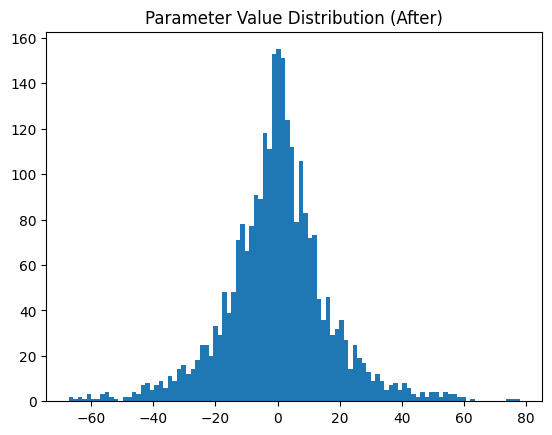

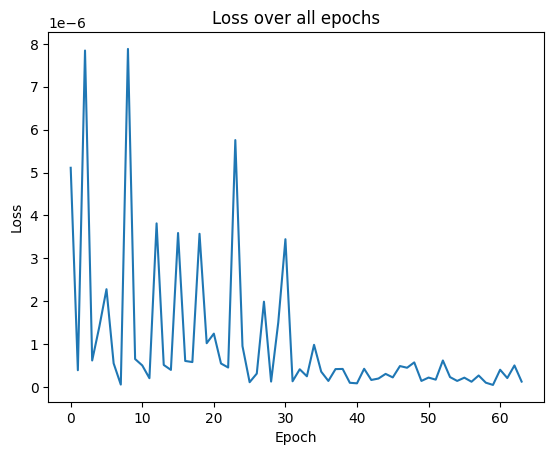

In [ ]:
model, val_loss = train_and_validate(dataloader_train_1, val_1, val_labels_1, par_plot=True, loss_plot=True)

# Hyperparametrar

Den lär sig lite, så pipelinen fungerar. Men det ser ju inte direkt jättebra ut, så innan vi kör våra tre riktiga experiment vill vi såklart ha något hum om vad som är rimliga hyperparametrar, även om vi kanske inte kommer att hitta globala maxima. Vi gör en grid search, men denna gång använder jag ett paket som verkar relativt SOTA (13.7k stjärnor på Github, borde vara OK). Exempel från docs:

```
import optuna

def objective(trial):
    x = trial.suggest_float('x', -10, 10)
    return (x - 2) ** 2

study = optuna.create_study()
study.optimize(objective, n_trials=100)

study.best_params  # E.g. {'x': 2.002108042}
```

In [2]:
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True) # som för vår manuella grid search i assignment 1, måste vi ge optuna plausibla övre och undre gränser för sökandet
    beta1 = trial.suggest_float("beta1", 0.8, 0.99) # som tur är har Adams första och andra moment som standard ett ganska litet parameeterrum; man ser sällan en beta långt från "0.9xxx"
    beta2 = trial.suggest_float("beta2", 0.9, 0.9999)
    eps = trial.suggest_float("eps", 1e-9, 1e-6, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    _, val_loss = train_and_validate(
        dataloader_train_1,
        val_1,
        val_labels_1,
        lr=lr,
        betas=(beta1, beta2),
        epsilon=eps,
        weight_decay=weight_decay,
        patience=10,
    )

    return val_loss

study = optuna.create_study(direction="minimize") # eftersom vår objective returnerar loss vill vi minimera. om vi hade haft acc hade satt direction="maximize"
study.optimize(objective, n_trials=50)

print("Best params:", study.best_params) # Resultat: {'lr': 0.004112400258487478, 'beta1': 0.9297307475101502, 'beta2': 0.9114747494792839, 'eps': 1.64237780147819e-09, 'weight_decay': 0.00010005454329620577}

[I 2026-03-20 15:22:08,217] A new study created in memory with name: no-name-bcbc49da-4610-4172-a7fb-4141cc31177c
[W 2026-03-20 15:22:08,218] Trial 0 failed with parameters: {'lr': 0.0001471989798033352, 'beta1': 0.9231680448088524, 'beta2': 0.979988024756678, 'eps': 3.071751608860829e-09, 'weight_decay': 0.0015333803956924731} because of the following error: NameError("name 'train_and_validate' is not defined").
Traceback (most recent call last):
  File "/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_3532320/1438238425.py", line 10, in objective
    _, val_loss = train_and_validate(
                  ^^^^^^^^^^^^^^^^^^
NameError: name 'train_and_validate' is not defined
[W 2026-03-20 15:22:08,218] Trial 0 failed with value None.


NameError: name 'train_and_validate' is not defined

# Experiment (evaluering)

## Evalueringsfunktion

Med en uppsättning bra parametrar i fickan kan vi nu experimenten. Först definierar vi en evalueringsfunktion.

Utöver test accuracy ger vi precision och recall på klassbasis.

In [21]:
import torch.nn.functional as F

def evaluate(model, test, test_labels):
    print(device)
    model.eval()
    model.to(device)
    test.to(device)
    test_labels.to(device)
    with torch.no_grad():
        logits = model.forward(test)
        predictions = F.softmax(logits, dim=1).argmax(dim=1)
        correct = (predictions == test_labels).sum().item()
        acc = correct / len(test_labels)
        print(f"Test Accuracy: {acc:.2f}")

    precision = []
    recall = []
    for cls in range(2):
        tp = ((predictions == cls) & (test_labels == cls)).sum().item() # true positives
        fp = ((predictions == cls) & (test_labels != cls)).sum().item() # false positives
        fn = ((predictions != cls) & (test_labels == cls)).sum().item() # false negatives

        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0 # precision: av alla som predicerades som cls (alla "positives"), hur många förutsas rätt?
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0 # recall: av alla som faktiskt var cls, hur många förutsas rätt?

        precision.append(p)
        recall.append(r)
        
        print(f"Class {cls}: Precision: {p:.2f}, Recall: {r:.2f}")

    return acc, precision, recall            

# for sentence, prediction in zip(sentences, predictions):
#     prediction = prediction.tolist()
#     print(f"{sentence[:30]}:\t\t {[f"{x:.2f}" for x in prediction]}")

## Experiment 1: Bara Emelies senantika/medeltida data

I detta experiment använder jag bara Emelies data, 90/10/10. Vi tränar en modell och sen testar vi den.

In [24]:

best_params_optuna = {'lr': 0.004112400258487478, 'beta1': 0.9297307475101502, 'beta2': 0.9114747494792839, 'eps': 1.64237780147819e-09, 'weight_decay': 0.00010005454329620577}

model_1, val_loss_1 = train_and_validate(
    dataloader_train_1, 
    val_1, val_labels_1, 
    lr=best_params_optuna["lr"], 
    betas=(best_params_optuna["beta1"], 
    best_params_optuna["beta2"]), 
    epsilon=best_params_optuna["eps"], 
    weight_decay=best_params_optuna["weight_decay"], 
    patience=10, 
    par_plot=True, 
    loss_plot=True, 
    verbose=False)




 72%|███████▏  | 72/100 [00:21<00:08,  3.39Epochs/s]

In [ ]:
acc, precision, recall = evaluate(
    model_1, 
    test_1, 
    test_labels_1)

Vi testar och jämför resultatet mot Emelies Qwen 3 som fick 0.88.